# Librairies and data

In [2]:
import numpy as np

import sys
sys.path.append('../../py_scripts')

from SPAC_Dataset import dataset
from models import *

In [3]:
HG002 = dataset(
    "/home/amergez/SPA-C/datasets_v2/HG002.B10M/SPA-C_ds/HG002.B10M.scaff_only.hdf5",
    bin_size=5000,
    image_size=10,
    skip_check=True
)
HG002.minmax(max_val=47.0)
HG002.summary()

DLScaff dataset v5.7

Loading /home/amergez/SPA-C/datasets_v2/HG002.B10M/SPA-C_ds/HG002.B10M.scaff_only.hdf5 ...
Done ! (1.16s)

Dataset metadata :
	Cool2InterM_FullMat.creation_date: 01/27/2026-15:05:19
	Cool2InterM_FullMat.filter: None
	Cool2InterM_FullMat.version: 1.11
	data.type: Inter.FullMat
	dataset: HG002.B10M.JHE

'HG002.B10M.JHE' dataset summary - BS:5000 IS:10

	The dataset has been normed.
	Whole dataset :
		x - (344568, 20, 20)
		y - (344568,)
		names - (344568,)
		groups - (344568,)
		0.0% of the samples are True


In [4]:
ID = 'chr1_MATERNAL_A:0-10167586:1|chr1_MATERNAL_B:0-10167586:0'
pos = np.where(HG002.N == ID)[0][0]
mat = HG002.X[pos]
pos

np.int64(4)

In [5]:
MATs = {}
MATs[0] = mat.copy()
for pad in range(1,4):
    print(pad)
    padded = mat.copy()
    padded[:pad,:] = 0
    padded[:,:pad] = 0
    
    MATs[pad] = padded

    padded = mat.copy()
    padded[-pad:,:] = 0
    padded[:,-pad:] = 0

    MATs[-pad] = padded

1
2
3


# Figure

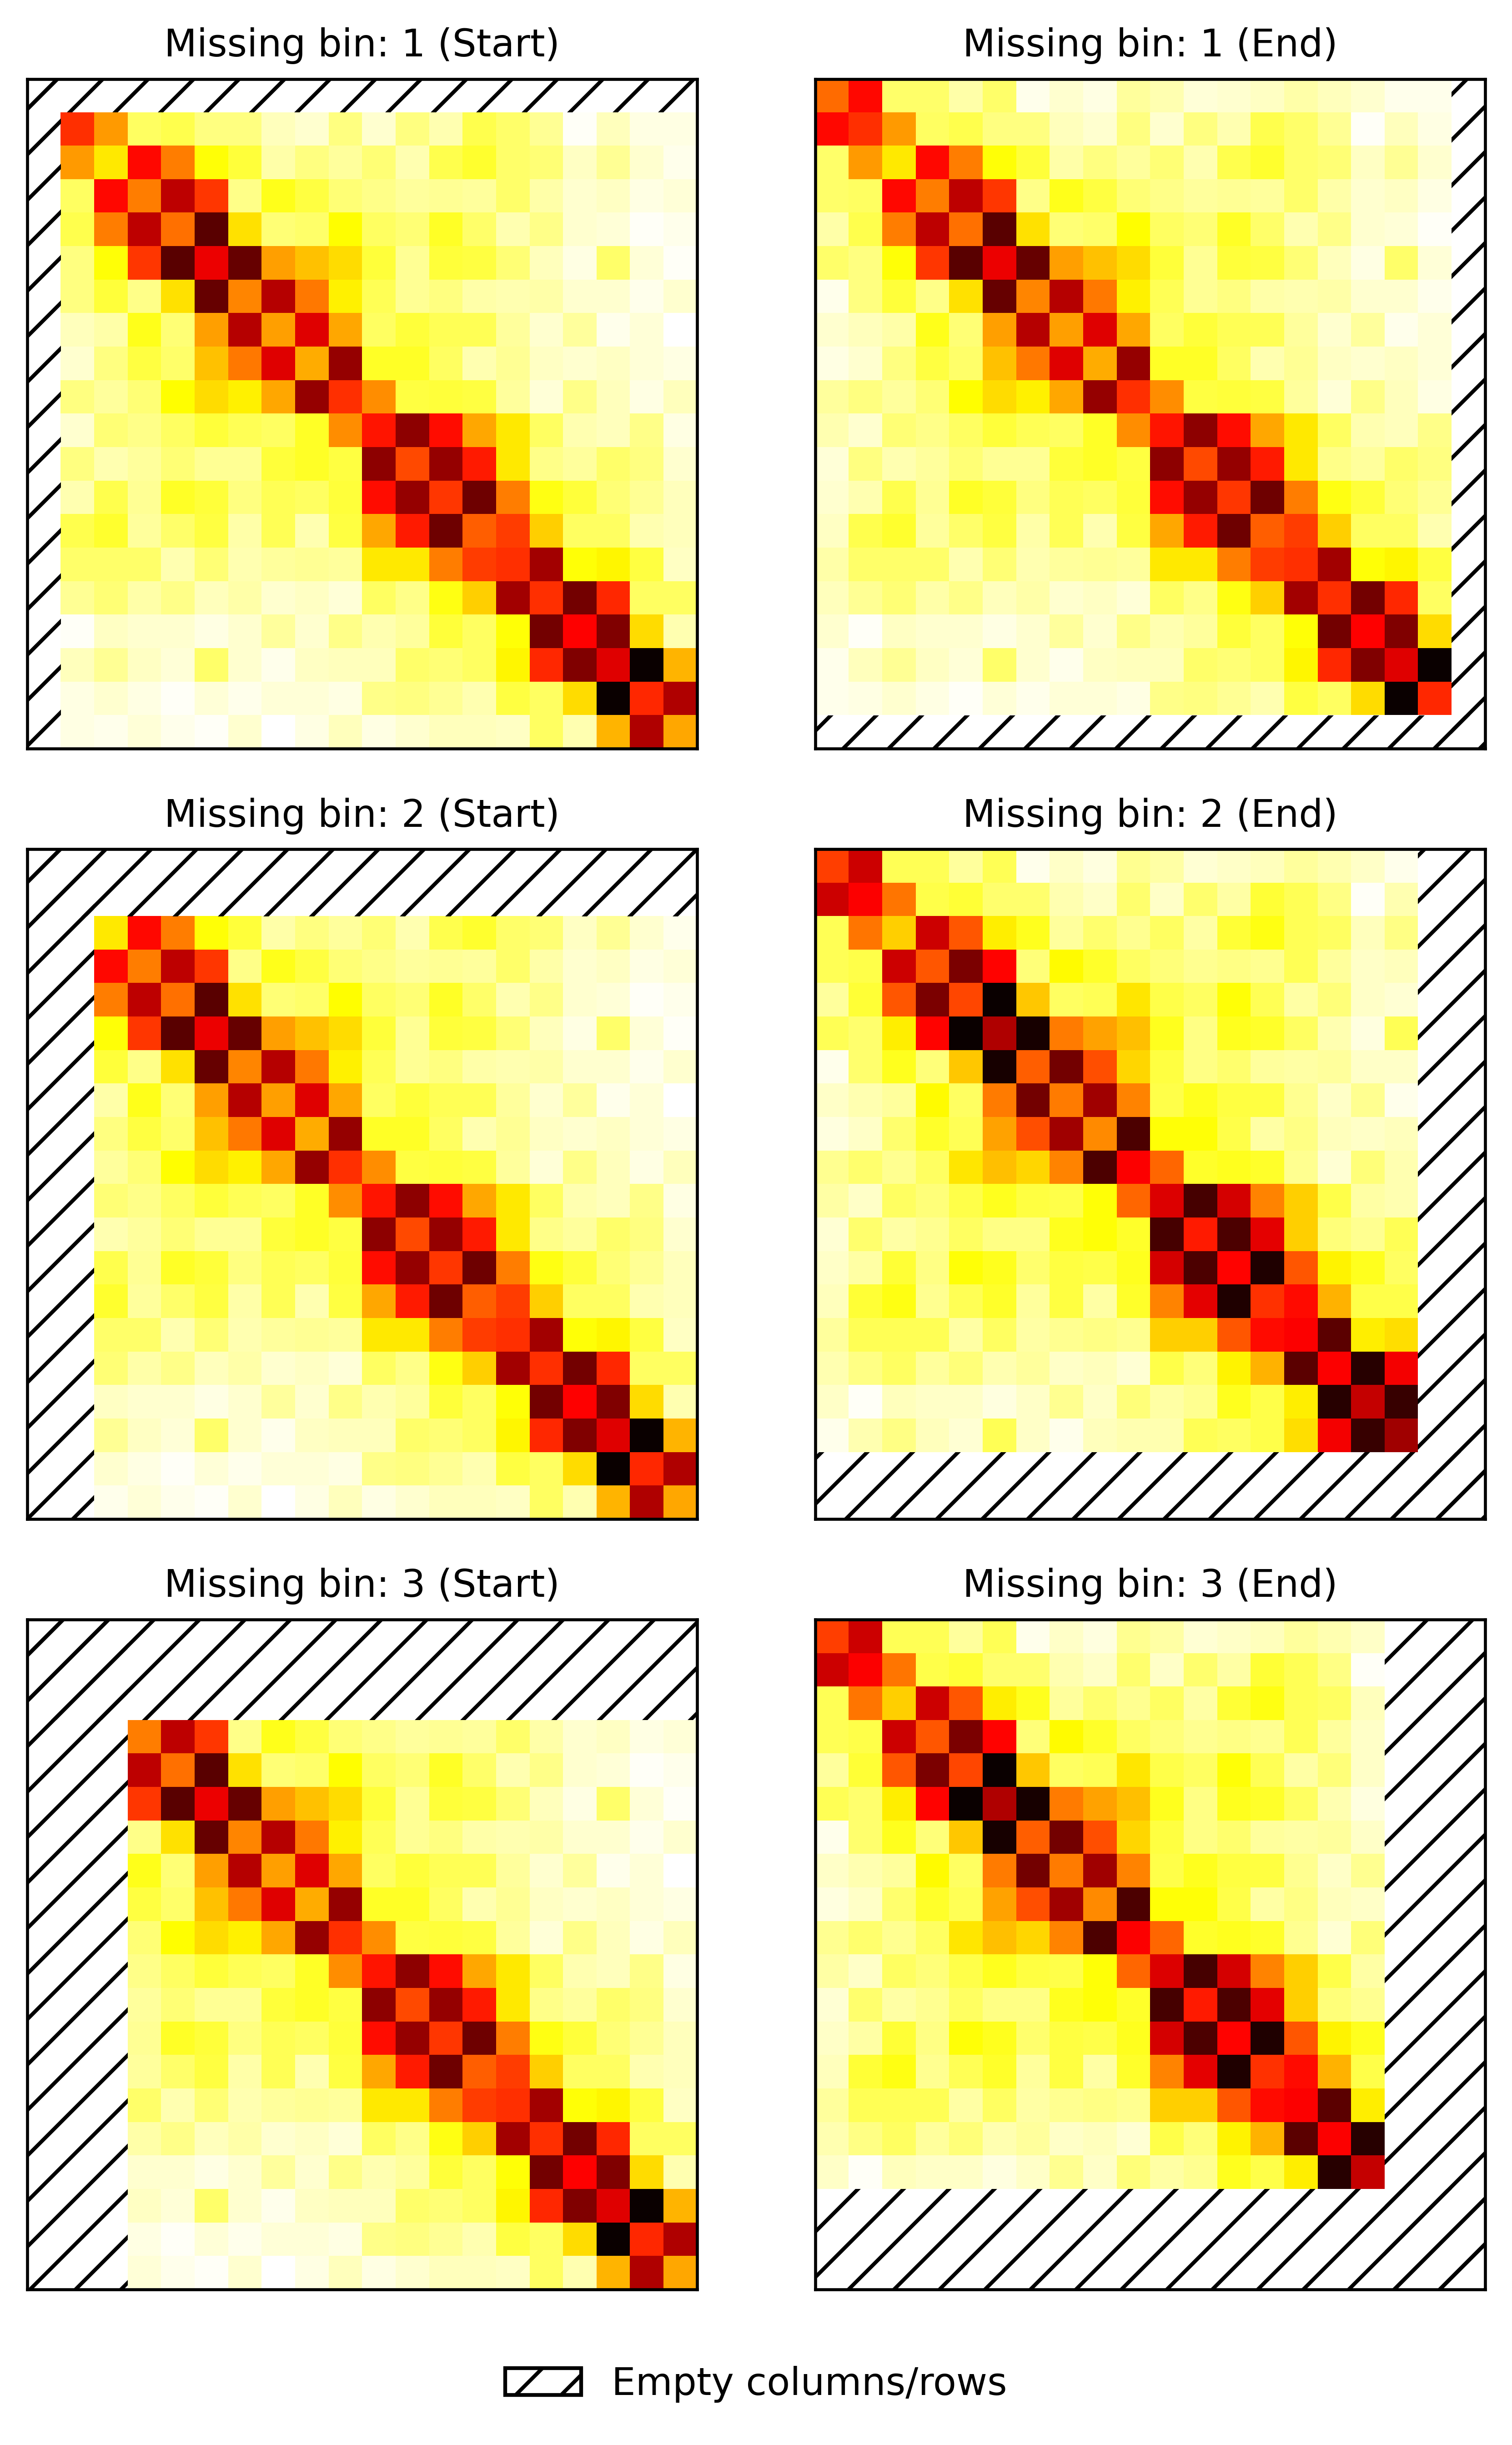

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

kmin = 1

fig, axs = plt.subplots(4-kmin,2, figsize=(6,(4-kmin)*3), dpi=600)
fs = 10
plt.rcParams.update({'font.size': fs, 'legend.fontsize':fs, 'figure.labelsize':fs})


for raw_K in range(kmin,4):
    K = raw_K-kmin if kmin != 0 else raw_K
    axs[K, 0].matshow(MATs[raw_K], cmap="hot_r")
    axs[K, 1].matshow(MATs[-(raw_K)], cmap="hot_r")

    for L in range(2):
        axs[K, L].tick_params(
                axis='both',          
                which='both',         
                bottom=False,         
                top=False,            
                left=False,           
                right=False,          
                labelbottom=False,    
                labeltop=False,       
                labelleft=False,      
                labelright=False      
            )
        axs[K, L].set_title(f"Missing bin: {raw_K} ({'Start' if L == 0 else 'End'})", fontsize=fs)
        if raw_K != 0:
            start = -.5 if L == 0 else 20-raw_K-.5
            end = raw_K-.5 if L == 0 else 20-.5
            axs[K, L].axvspan(start, end, alpha=0, color=None, facecolor=None, hatch="//")
            axs[K, L].axhspan(start, end, alpha=0, color=None, facecolor=None, hatch="//")

hatch_proxy = mpatches.Patch(
                alpha=1, color="Black",
                hatch="//",
    fill=False,
                label='Missing rows/columns'
            )
fig.legend([hatch_proxy], ["Empty columns/rows"], loc='lower center', ncol=1, bbox_to_anchor=(0.5, -0.01), frameon=True, facecolor='white', edgecolor='none')

plt.subplots_adjust(
        left=0.05,
        right=0.95,
        bottom=0.05,
        top=0.95,
        wspace=0.15,
        hspace=0.15
    )

plt.savefig(f"SUPP.PAPER.MissingBins.png")
plt.show()